# Problem 2: Vowel classification from acoustic features

In [1]:
import os
import librosa
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel
from itertools import combinations
from collections import defaultdict
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, KFold

## Feature preparation

In [2]:
data_dir = "./hw1_data"
out_dir = "./output"
vis_out_dir = os.path.join(out_dir, "problem2")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(vis_out_dir, exist_ok=True)
extracted_formants_df = pd.read_csv(f"{out_dir}/extracted_formants.csv")
extracted_formants_df['talker_id'] = extracted_formants_df['File'].apply(lambda x: x[:3])
extracted_formants_df.rename(columns={'File': 'file_id'}, inplace=True)
print(extracted_formants_df.head())

  file_id  Start    End  Center1  Center2 group  steady_start  steady_end  \
0   m01ae  177.3  500.4    304.0    297.0   men         247.2       353.8   
1   m02ae  132.0  382.0    198.0    240.0   men         177.8       260.2   
2   m03ae  118.0  462.0    162.0    181.0   men         118.0       228.3   
3   m04ae   96.0  408.0    130.0    169.0   men          98.0       201.0   
4   m06ae   71.0  325.0    113.0    134.0   men          81.6       165.4   

           f0          f1           f2           f3           f4 talker_id  
0  166.382381  660.128601  1972.395731  2321.021218  2717.320826       m01  
1  100.729596  640.905347  1802.378084  2419.058693  3396.162065       m02  
2   95.409315  609.936178  1780.819994  2560.580271  3538.351487       m03  
3  125.555046  630.551106  1925.831368  2444.275535  3389.700486       m04  
4  117.960733  654.601432  1846.140090  2554.345163  3607.873357       m06  


In [3]:
feature_table_1_path = f"{out_dir}/feature_table_1.csv"
feature_table_2_path = f"{out_dir}/feature_table_2.csv"
feature_table_3_path = f"{out_dir}/feature_table_3.csv"
os.makedirs(out_dir, exist_ok=True)

if not os.path.exists(feature_table_1_path):
    feature_table_1 = extracted_formants_df[['file_id', 'talker_id', 'f1', 'f2']].copy()
    feature_table_1.to_csv(feature_table_1_path, index=False)
else:
    feature_table_1 = pd.read_csv(feature_table_1_path)
if not os.path.exists(feature_table_2_path):
    feature_table_2 = extracted_formants_df[['file_id', 'talker_id', 'f0', 'f1', 'f2']].copy()
    feature_table_2.to_csv(feature_table_2_path, index=False)
else:
    feature_table_2 = pd.read_csv(feature_table_2_path)


In [4]:
if not os.path.exists(feature_table_3_path):
    feature_table_3 = []
    for _, row in extracted_formants_df.iterrows():
        wav, sr = librosa.load(os.path.join(data_dir, row["file_id"] + ".wav"))
        steady_start = row["steady_start"] / 1000
        steady_end = row["steady_end"] / 1000
        steady_wav = wav[int(steady_start * sr):int(steady_end * sr)]

        win_length = 512 # roughly 25 ms window length at 20 kHz sampling rate
        hop_length = int(0.010 * sr)  # 10 ms hop length

        # win_length <= n_fft < signal_length, steady_state window is roughly 50ms
        mfccs = librosa.feature.mfcc(y=steady_wav, sr=sr, n_mfcc=13, win_length=win_length, hop_length=hop_length, n_fft=win_length)
        feature_table_3.append({
            "file_id": row["file_id"],
            "talker_id": row["talker_id"],
            **{"mfccs_{}".format(i): mfcc.mean() for i, mfcc in enumerate(mfccs)}
        })
    feature_table_3 = pd.DataFrame(feature_table_3)
    feature_table_3.to_csv(feature_table_3_path, index=False)
else:
    feature_table_3 = pd.read_csv(feature_table_3_path)

##  Speaker-independent 5-fold cross-validation

In [5]:
num_speakers = extracted_formants_df["talker_id"].nunique()

men_speakers = extracted_formants_df[extracted_formants_df["group"] == "men"]["talker_id"].unique()
women_speakers = extracted_formants_df[extracted_formants_df["group"] == "women"]["talker_id"].unique()
children_speakers = extracted_formants_df[extracted_formants_df["group"] == "children"]["talker_id"].unique()

men_cv, men_k_select = train_test_split(men_speakers, test_size=0.2, random_state=42)
women_cv, women_k_select = train_test_split(women_speakers, test_size=0.2, random_state=42)

print("Men #cv: {}, #k_select: {}".format(len(men_cv), len(men_k_select)))
print("Women #cv: {}, #k_select: {}".format(len(women_cv), len(women_k_select)))

Men #cv: 36, #k_select: 9
Women #cv: 38, #k_select: 10


### Select k

In [6]:
k_select_metadata_df = []
for unique_speaker in extracted_formants_df["talker_id"].unique():
    if unique_speaker in list(men_k_select) + list(women_k_select):
        k_select_metadata_df.append({"talker_id": unique_speaker, "split": "k_select"})
k_select_metadata_df = pd.DataFrame(k_select_metadata_df)
k_select_train, k_select_test = train_test_split(k_select_metadata_df, test_size=0.2, random_state=42)

class Dataloader:
    def __init__(self, data_df, metadata_df): 
        self.metadata_df = metadata_df.copy()
        self.data_df = data_df[data_df["talker_id"].isin(self.metadata_df["talker_id"])].copy()
        self.data_df['vowel'] = self.data_df['file_id'].apply(lambda x: x[-2:])

        self.X = self.data_df.drop(columns=["file_id", "talker_id", "vowel"])
        self.y = self.data_df["vowel"]

    def get_data(self):
        # split the data into train 
        return self.X, self.y.values

def train_knn(train_dataloader, test_dataloader, k_candidates):
    X_train, y_train = train_dataloader.get_data()
    X_test, y_test = test_dataloader.get_data()
    
    best_k = None
    best_accuracy = 0
    results = []
    for k in k_candidates:
        model = make_pipeline(
            StandardScaler(), # Standardize features since F2 and F1 may have different scales
            KNeighborsClassifier(n_neighbors=k)
        )

        model.fit(X_train, y_train)
        accuracy = model.score(X_test, y_test)

        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_k = k

        results.append({"k": k, "accuracy": accuracy})
    return best_k, best_accuracy, results

In [7]:
# build a k-nearest neighbors classifier 
k_candidates = [1, 3, 5, 7, 9, 11]

k_results = defaultdict(list)
for feature_table, feature_name in [(feature_table_1, "F1, F2"), (feature_table_2, "F0, F1, F2"), (feature_table_3, "MFCCs")]:
    k_select_train_loader = Dataloader(feature_table, k_select_train)
    k_select_test_loader = Dataloader(feature_table, k_select_test)
    best_k, best_accuracy, details = train_knn(k_select_train_loader, k_select_test_loader, k_candidates)

    for result in details:
        k_results[result["k"]].append(result["accuracy"])

k_results = {k: np.mean(v).item() for k, v in k_results.items()}
best_k = max(k_results, key=k_results.get)
best_accuracy = k_results[best_k]
print("Best k:", best_k, "Best accuracy: {:.3f}".format(best_accuracy))

Best k: 3 Best accuracy: 0.701


### 5-fold Cross Validation

In [8]:
cv_speakers = pd.DataFrame({
    'talker_id': np.concatenate([men_cv, women_cv]),
    'split': "cv"
})

folds = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

models = defaultdict(lambda: defaultdict(dict))
for feature_table, feature_name in [(feature_table_1, "feature_table_1"), (feature_table_2, "feature_table_2"), (feature_table_3, "feature_table_3")]:
    for fold_idx, (train_idx, test_idx) in enumerate(
        folds.split(cv_speakers)
    ):
        train_speakers = cv_speakers.iloc[train_idx]
        test_speakers = cv_speakers.iloc[test_idx]

        train_loader = Dataloader(data_df=feature_table, metadata_df=train_speakers)
        test_loader = Dataloader(data_df=feature_table, metadata_df=test_speakers)

        X_train, y_train = train_loader.get_data()
        X_test, y_test = test_loader.get_data()

        model = make_pipeline(
            StandardScaler(),
            KNeighborsClassifier(n_neighbors=best_k)
        )

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)

        models[feature_name][fold_idx] = {
            "model": model,
            "accuracy": accuracy,
            "y_true": np.array(y_test),
            "y_pred": np.array(y_pred),
        }

In [9]:
for feature_name, folds_dict in models.items():
    for fold_idx, items in folds_dict.items():
        accuracy = items["accuracy"]
        print(f"Feature: {feature_name}, Fold: {fold_idx}, Accuracy: {accuracy:.3f}")

Feature: feature_table_1, Fold: 0, Accuracy: 0.639
Feature: feature_table_1, Fold: 1, Accuracy: 0.689
Feature: feature_table_1, Fold: 2, Accuracy: 0.661
Feature: feature_table_1, Fold: 3, Accuracy: 0.639
Feature: feature_table_1, Fold: 4, Accuracy: 0.589
Feature: feature_table_2, Fold: 0, Accuracy: 0.728
Feature: feature_table_2, Fold: 1, Accuracy: 0.756
Feature: feature_table_2, Fold: 2, Accuracy: 0.744
Feature: feature_table_2, Fold: 3, Accuracy: 0.733
Feature: feature_table_2, Fold: 4, Accuracy: 0.720
Feature: feature_table_3, Fold: 0, Accuracy: 0.739
Feature: feature_table_3, Fold: 1, Accuracy: 0.744
Feature: feature_table_3, Fold: 2, Accuracy: 0.744
Feature: feature_table_3, Fold: 3, Accuracy: 0.711
Feature: feature_table_3, Fold: 4, Accuracy: 0.744


In [10]:
name_map = {
    "feature_table_1": "F1/F2",
    "feature_table_2": "F0/F1/F2",
    "feature_table_3": "MFCCs",
}

fold_accs = {}
features = list(models.keys())
results = {}

for feature in features:
    y_true_all = np.concatenate([
        models[feature][i]["y_true"]
        for i in sorted(models[feature].keys())
    ])

    y_pred_all = np.concatenate([
        models[feature][i]["y_pred"]
        for i in sorted(models[feature].keys())
    ])

    labels = sorted(np.unique(y_true_all))

    cm = confusion_matrix(
        y_true_all,
        y_pred_all,
        labels=labels
    )

    accs = [
        accuracy_score(
            models[feature][i]["y_true"],
            models[feature][i]["y_pred"]
        )
        for i in sorted(models[feature].keys())
    ]

    results[feature] = {
        "cm": cm,
        "labels": labels,
        "accuracies": accs
    }

    print(f"{name_map[feature]}: {np.mean(accs):.3f} ± {np.std(accs, ddof=1):.3f}")

F1/F2: 0.643 ± 0.037
F0/F1/F2: 0.736 ± 0.014
MFCCs: 0.737 ± 0.014


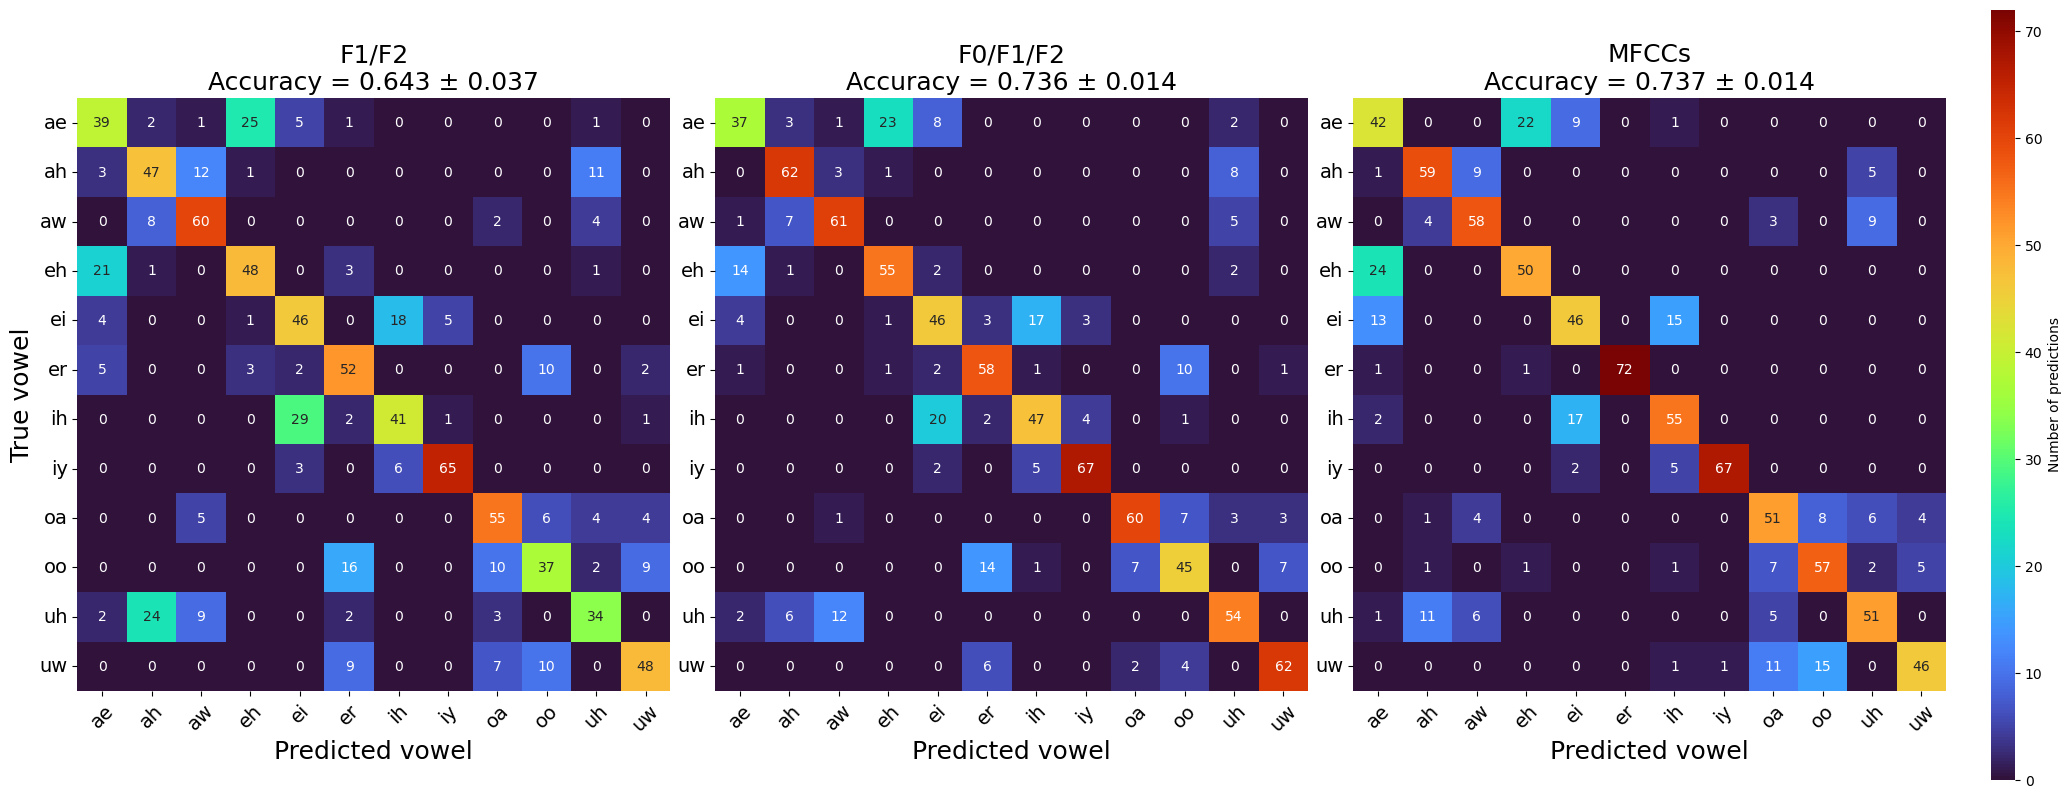

In [11]:
fig = plt.figure(figsize=(25, 10))

gs = fig.add_gridspec(
    1, 4,
    width_ratios=[1, 1, 1, 0.04],
    wspace=0.1
)

axes = [fig.add_subplot(gs[0, i]) for i in range(3)]
cbar_ax = fig.add_subplot(gs[0, 3])
vmax = max(result["cm"].max() for result in results.values())
best_feature_acc = 0
best_feature_table = None
for idx, feature in enumerate(features):
    result = results[feature]

    sns.heatmap(
        result["cm"],
        annot=True,
        fmt="d",
        cmap="turbo",
        vmin=0,
        vmax=vmax,
        square=True,
        xticklabels=result["labels"],
        yticklabels=result["labels"],
        ax=axes[idx],
        cbar=(idx == len(features) - 1),
        cbar_ax=cbar_ax if idx == len(features) - 1 else None,
    )

    axes[idx].set_title(
        f"{name_map[feature]}\n"
        f"Accuracy = {np.mean(result['accuracies']):.3f} ± {np.std(result['accuracies'], ddof=1):.3f}",
        fontsize=18
    )
    axes[idx].set_xlabel("Predicted vowel", fontsize=18)

    if idx == 0:
        axes[idx].set_ylabel("True vowel", fontsize=18)
    else:
        axes[idx].set_ylabel("", fontsize=18)

    axes[idx].tick_params(axis="x", rotation=45, labelsize=14)
    axes[idx].tick_params(axis="y", rotation=0, labelsize=14)

    if np.mean(result['accuracies']) > best_feature_acc:
        best_feature_acc = np.mean(result['accuracies'])
        best_feature_table = feature
cbar_ax.set_ylabel("Number of predictions")

plt.savefig(os.path.join(vis_out_dir, "confusion_matrices.pdf"))
plt.show()

Calculating the most confused vowel pair(s) for the best-performing feature set.

In [12]:
labels = results[best_feature_table]["labels"]
pair_confusions = []
for i in range(len(labels)):
    for j in range(i + 1, len(labels)):
        cm = results[best_feature_table]["cm"]
        total_confusion = cm[i, j] + cm[j, i]

        pair_confusions.append(
            (labels[i], labels[j], total_confusion,
             cm[i, j], cm[j, i])
        )

pair_confusions = sorted(
    pair_confusions,
    key=lambda x: x[2],
    reverse=True
)

for v1, v2, total, v1_to_v2, v2_to_v1 in pair_confusions[:5]:
    print(
        f"{v1} <-> {v2}: {total} "
        f"({v1}->{v2}: {v1_to_v2}, "
        f"{v2}->{v1}: {v2_to_v1})"
    )

ae <-> eh: 46 (ae->eh: 22, eh->ae: 24)
ei <-> ih: 32 (ei->ih: 15, ih->ei: 17)
ae <-> ei: 22 (ae->ei: 9, ei->ae: 13)
oo <-> uw: 20 (oo->uw: 5, uw->oo: 15)
ah <-> uh: 16 (ah->uh: 5, uh->ah: 11)


Bonferroni-corrected alpha = 0.0167
----------------------------------------
F1/F2 vs F0/F1/F2: p = 0.0009, p_adj = 0.0028
F1/F2 vs MFCCs: p = 0.0054, p_adj = 0.0162
F0/F1/F2 vs MFCCs: p = 0.9706, p_adj = 1.0000


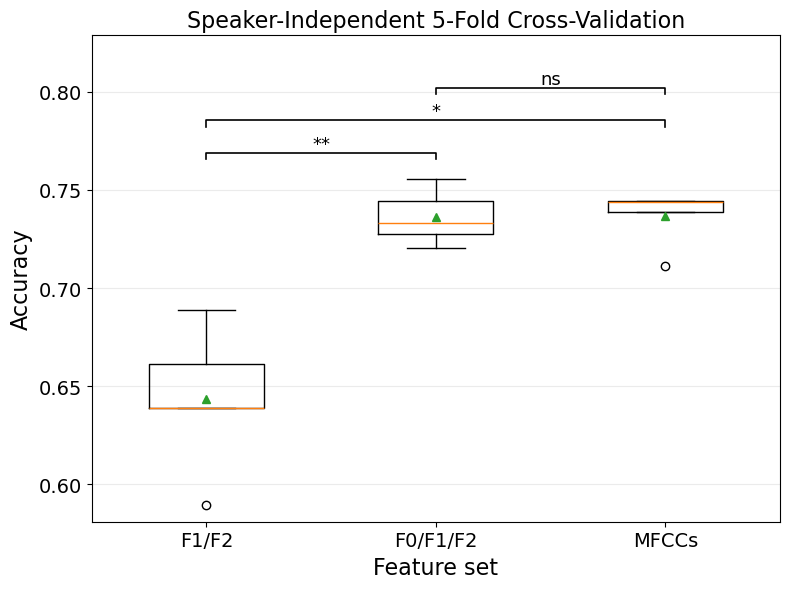

In [13]:
feature_names = list(name_map.keys())

alpha = 0.05
n_comparisons = 3
bonferroni_alpha = alpha / n_comparisons


pairwise_results = {}
print(f"Bonferroni-corrected alpha = {bonferroni_alpha:.4f}")
print("-" * 40)
for f1, f2 in combinations(feature_names, 2):
    acc1 = results[f1]["accuracies"]
    acc2 = results[f2]["accuracies"]

    t_stat, p_value = ttest_rel(acc1, acc2)

    # Bonferroni-adjusted p-value
    p_adj = min(p_value * n_comparisons, 1.0)

    pairwise_results[(f1, f2)] = {
        "p": p_value,
        "p_adj": p_adj,
    }

    print(
        f"{name_map[f1]} vs {name_map[f2]}: "
        f"p = {p_value:.4f}, "
        f"p_adj = {p_adj:.4f}"
    )


def p_to_stars(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"


def add_significance_bar(ax, x1, x2, y, h, text):
    """Draw pairwise significance bracket."""
    ax.plot(
        [x1, x1, x2, x2],
        [y, y + h, y + h, y],
        linewidth=1.2,
        c="black"
    )

    ax.text(
        (x1 + x2) / 2,
        y + h,
        text,
        ha="center",
        va="bottom",
        fontsize=13
    )


# Boxplot
fig, ax = plt.subplots(figsize=(8, 6))

data = [results[name]["accuracies"] for name in feature_names]
labels = [name_map[name] for name in feature_names]

ax.boxplot(
    data,
    tick_labels=labels,
    showmeans=True,
    widths=0.5
)

ax.set_ylabel("Accuracy", fontsize=16)
ax.set_xlabel("Feature set", fontsize=16)
ax.set_title(
    "Speaker-Independent 5-Fold Cross-Validation",
    fontsize=16
)

ax.tick_params(axis="x", labelsize=14)
ax.tick_params(axis="y", labelsize=14)
ax.grid(axis="y", alpha=0.25)


# Add pairwise significance brackets
all_values = np.concatenate(data)
data_max = all_values.max()
data_min = all_values.min()
data_range = data_max - data_min

positions = {
    feature_names[0]: 1,
    feature_names[1]: 2,
    feature_names[2]: 3,
}


base_y = data_max + 0.06 * data_range
step = 0.10 * data_range
h = 0.02 * data_range

for idx, ((f1, f2), stats) in enumerate(pairwise_results.items()):
    x1 = positions[f1]
    x2 = positions[f2]

    y = base_y + idx * step
    stars = p_to_stars(stats["p_adj"])
    add_significance_bar(
        ax,
        x1,
        x2,
        y,
        h,
        stars
    )

ax.set_ylim(
    data_min - 0.05 * data_range,
    base_y + len(pairwise_results) * step + 0.08 * data_range
)

plt.tight_layout()
plt.savefig(
    os.path.join(vis_out_dir, "cross_validation_results.pdf"),
    bbox_inches="tight"
)
plt.show()

##  Generalization to children: raw vs. VTL-normalized formants

### Result on Children

In [14]:
F1_F2_models = models['feature_table_1']
children_loader = Dataloader(feature_table_1, pd.DataFrame({"talker_id": children_speakers}))
X_children, y_children = children_loader.get_data()

adults_accuracies = []
children_accuracies = []
for fold_name, fold in F1_F2_models.items():
    model = fold['model']
    y_pred = model.predict(X_children)
    accuracy = accuracy_score(y_children, y_pred)
    children_accuracies.append(accuracy)
    adults_accuracies.append(fold['accuracy'])

print("Mean accuracy (adults): {:.4f}, Std accuracy: {:.4f}".format(np.mean(adults_accuracies), np.std(adults_accuracies)))
print("Mean accuracy (children): {:.4f}, Std accuracy: {:.4f}".format(np.mean(children_accuracies), np.std(children_accuracies)))
print("Performance gap: {:.4f}".format(np.mean(adults_accuracies) - np.mean(children_accuracies)))

Mean accuracy (adults): 0.6434, Std accuracy: 0.0327
Mean accuracy (children): 0.3511, Std accuracy: 0.0060
Performance gap: 0.2923


### VTL-normalized result on children

In [15]:
normalized_feature_table = pd.read_csv(os.path.join(out_dir,"normalized_vowelspace.csv"))[['File', 'f1', 'f2']]
normalized_feature_table.rename(columns={'File': 'file_id'}, inplace=True)
normalized_feature_table['talker_id'] = normalized_feature_table['file_id'].apply(lambda x: x[:3])

In [16]:
vtl_normalized_models = defaultdict(lambda: defaultdict(dict))
for fold_idx, (train_idx, test_idx) in enumerate(
    folds.split(cv_speakers)
):
    train_speakers = cv_speakers.iloc[train_idx]
    test_speakers = cv_speakers.iloc[test_idx]

    train_loader = Dataloader(data_df=normalized_feature_table, metadata_df=train_speakers)
    test_loader = Dataloader(data_df=normalized_feature_table, metadata_df=test_speakers)

    X_train, y_train = train_loader.get_data()
    X_test, y_test = test_loader.get_data()

    model = make_pipeline(
        StandardScaler(),
        KNeighborsClassifier(n_neighbors=best_k)
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)

    vtl_normalized_models[fold_idx] = {
        "model": model,
        "accuracy": accuracy,
        "y_true": np.array(y_test),
        "y_pred": np.array(y_pred),
    }

In [17]:
vtl_normalized_children_loader = Dataloader(normalized_feature_table, pd.DataFrame({"talker_id": children_speakers}))
X_vtl_normalized_children, y_vtl_normalized_children = vtl_normalized_children_loader.get_data()
    
vtl_normalized_adults_accuracies = []
vtl_normalized_children_accuracies = []
for fold_name, fold in vtl_normalized_models.items():
    model = fold['model']
    y_pred = model.predict(X_vtl_normalized_children)
    accuracy = accuracy_score(y_vtl_normalized_children, y_pred)
    vtl_normalized_children_accuracies.append(accuracy)
    vtl_normalized_adults_accuracies.append(fold['accuracy'])
print("Mean accuracy (adults, VTL normalized): {:.4f}, Std accuracy: {:.4f}".format(np.mean(vtl_normalized_adults_accuracies), np.std(vtl_normalized_adults_accuracies)))
print("Mean accuracy (children, VTL normalized): {:.4f}, Std accuracy: {:.4f}".format(np.mean(vtl_normalized_children_accuracies), np.std(vtl_normalized_children_accuracies)))
print("Performance gap (VTL normalized): {:.4f}".format(np.mean(vtl_normalized_adults_accuracies) - np.mean(vtl_normalized_children_accuracies)))

Mean accuracy (adults, VTL normalized): 0.6226, Std accuracy: 0.0366
Mean accuracy (children, VTL normalized): 0.4156, Std accuracy: 0.0041
Performance gap (VTL normalized): 0.2070


### Plotting the differences

Raw adult vs. child p-value: 6.57570249271792e-05
VTL-normalized adult vs. child p-value: 0.00038830941774396365


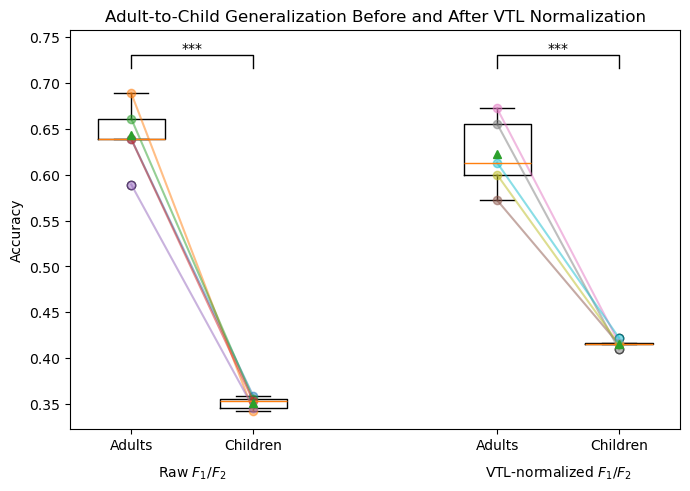

In [ ]:
raw_adult_acc = np.array(adults_accuracies)
raw_child_acc = np.array(children_accuracies)

vtl_adult_acc = np.array(vtl_normalized_adults_accuracies)
vtl_child_acc = np.array(vtl_normalized_children_accuracies)

# Adult vs. child significance within each condition
_, p_raw = ttest_rel(raw_adult_acc, raw_child_acc)
_, p_vtl = ttest_rel(vtl_adult_acc, vtl_child_acc)

print(f"Raw adult vs. child p-value: {p_raw}")
print(f"VTL-normalized adult vs. child p-value: {p_vtl}")

fig, ax = plt.subplots(figsize=(7, 5))
positions = [1, 2, 4, 5]

ax.boxplot(
    [
        raw_adult_acc,
        raw_child_acc,
        vtl_adult_acc,
        vtl_child_acc,
    ],
    positions=positions,
    tick_labels=[
        "Adults",
        "Children",
        "Adults",
        "Children",
    ],
    widths=0.55,
    showmeans=True,
)

for i in range(len(raw_adult_acc)):
    ax.plot(
        [1, 2],
        [raw_adult_acc[i], raw_child_acc[i]],
        marker="o",
        alpha=0.5,
    )

for i in range(len(vtl_adult_acc)):
    ax.plot(
        [4, 5],
        [vtl_adult_acc[i], vtl_child_acc[i]],
        marker="o",
        alpha=0.5,
    )

ax.set_ylabel("Accuracy")
ax.set_title("Adult-to-Child Generalization Before and After VTL Normalization")


ax.text(
    1.5, -0.12,
    "Raw $F_1/F_2$",
    ha="center",
    transform=ax.get_xaxis_transform(),
)

ax.text(
    4.5, -0.12,
    "VTL-normalized $F_1/F_2$",
    ha="center",
    transform=ax.get_xaxis_transform(),
)

all_acc = np.concatenate([
    raw_adult_acc,
    raw_child_acc,
    vtl_adult_acc,
    vtl_child_acc,
])

y_max = all_acc.max()
y_min = all_acc.min()
offset = (y_max - y_min) * 0.08

# Raw adult vs. child
y1 = y_max + offset

ax.plot(
    [1, 1, 2, 2],
    [y1, y1 + offset / 2, y1 + offset / 2, y1],
    linewidth=1,
    color="black",
)

ax.text(
    1.5,
    y1 + offset / 2,
    p_to_stars(p_raw),
    ha="center",
    va="bottom",
)

# Normalized adult vs. child
y2 = y_max + offset

ax.plot(
    [4, 4, 5, 5],
    [y2, y2 + offset / 2, y2 + offset / 2, y2],
    linewidth=1,
    color="black",
)

ax.text(
    4.5,
    y2 + offset / 2,
    p_to_stars(p_vtl),
    ha="center",
    va="bottom",
)

ax.set_ylim(top=y_max + offset * 2.5)

plt.tight_layout()
plt.savefig(
    os.path.join(vis_out_dir, "vtl_normalization_effect.pdf"),
    bbox_inches="tight",
)
plt.show()

Evaluate whether VTL normalization significantly reduces the adult-to-child generalization gap across the same five folds.

In [19]:
raw_diff = raw_adult_acc - raw_child_acc
vtl_diff = vtl_adult_acc - vtl_child_acc

# compute paired t-tests
_, p_raw_diff_vs_vtl_diff = ttest_rel(raw_diff, vtl_diff)
print("p-value for raw_diff vs vtl_diff:", p_raw_diff_vs_vtl_diff)

p-value for raw_diff vs vtl_diff: 0.002832382750249004


## MFCCs and generalization

In [20]:
MFCCs_models = models['feature_table_3']
children_loader = Dataloader(feature_table_3, pd.DataFrame({"talker_id": children_speakers}))
X_children, y_children = children_loader.get_data()

adults_mfcc_accuracies = []
children_mfcc_accuracies = []
for fold_name, fold in MFCCs_models.items():
    model = fold['model']
    y_pred = model.predict(X_children)
    accuracy = accuracy_score(y_children, y_pred)
    children_mfcc_accuracies.append(accuracy)
    adults_mfcc_accuracies.append(fold['accuracy'])

print("MFCCs:")
print("Mean accuracy (adults): {:.4f}, Std accuracy: {:.4f}".format(np.mean(adults_mfcc_accuracies), np.std(adults_mfcc_accuracies)))
print("Mean accuracy (children): {:.4f}, Std accuracy: {:.4f}".format(np.mean(children_mfcc_accuracies), np.std(children_mfcc_accuracies)))
print("Performance gap: {:.4f}".format(np.mean(adults_mfcc_accuracies) - np.mean(children_mfcc_accuracies)))

MFCCs:
Mean accuracy (adults): 0.7366, Std accuracy: 0.0129
Mean accuracy (children): 0.6308, Std accuracy: 0.0111
Performance gap: 0.1058


In [21]:
raw_f1f2_drop = (
    np.array(adults_accuracies)
    - np.array(children_accuracies)
)

mfcc_drop = (
    np.array(adults_mfcc_accuracies)
    - np.array(children_mfcc_accuracies)
)

t_stat, p_value = ttest_rel(
    raw_f1f2_drop,
    mfcc_drop
)
print("T-test between raw F1/F2 drop and MFCC drop:")
print("t-statistic: {:.4f}, p-value: {:.4f}".format(t_stat, p_value))
if p_value < 0.05:
    print("The difference is statistically significant.")
    if raw_f1f2_drop.mean() > mfcc_drop.mean():
        print("Raw F1/F2 drop is significantly larger than MFCC drop.")
    else:
        print("MFCC drop is significantly larger than Raw F1/F2 drop.")
else:
    print("The difference is not statistically significant.")

T-test between raw F1/F2 drop and MFCC drop:
t-statistic: 9.4442, p-value: 0.0007
The difference is statistically significant.
Raw F1/F2 drop is significantly larger than MFCC drop.


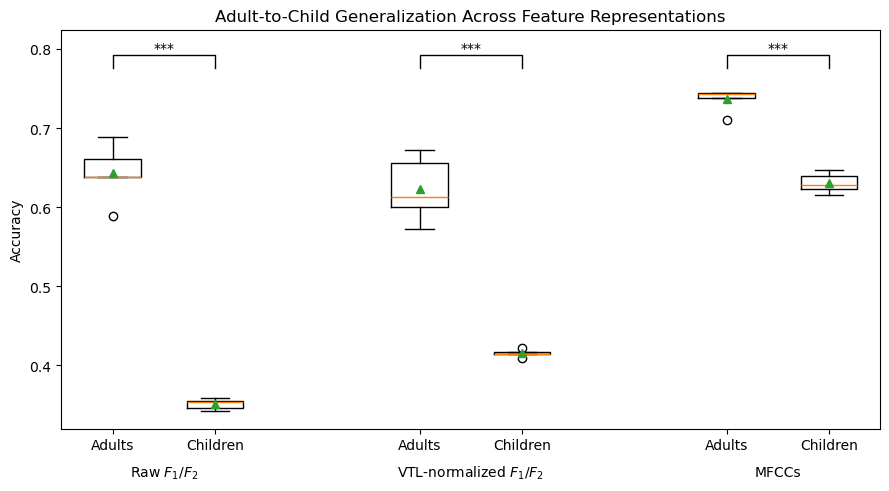

In [ ]:
mfcc_adult_acc = np.array(adults_mfcc_accuracies)
mfcc_child_acc = np.array(children_mfcc_accuracies)
_, p_mfcc = ttest_rel(mfcc_adult_acc, mfcc_child_acc)

fig, ax = plt.subplots(figsize=(9, 5))


positions = [1, 2, 4, 5, 7, 8]

ax.boxplot(
    [
        raw_adult_acc,
        raw_child_acc,
        vtl_adult_acc,
        vtl_child_acc,
        mfcc_adult_acc,
        mfcc_child_acc,
    ],
    positions=positions,
    tick_labels=[
        "Adults",
        "Children",
        "Adults",
        "Children",
        "Adults",
        "Children",
    ],
    widths=0.55,
    showmeans=True,
)


ax.set_ylabel("Accuracy")
ax.set_title("Adult-to-Child Generalization Across Feature Representations")

# Feature labels
ax.text(
    1.5, -0.12,
    "Raw $F_1/F_2$",
    ha="center",
    transform=ax.get_xaxis_transform(),
)

ax.text(
    4.5, -0.12,
    "VTL-normalized $F_1/F_2$",
    ha="center",
    transform=ax.get_xaxis_transform(),
)

ax.text(
    7.5, -0.12,
    "MFCCs",
    ha="center",
    transform=ax.get_xaxis_transform(),
)

all_acc = np.concatenate([
    raw_adult_acc,
    raw_child_acc,
    vtl_adult_acc,
    vtl_child_acc,
    mfcc_adult_acc,
    mfcc_child_acc,
])

y_max = all_acc.max()
y_min = all_acc.min()
offset = (y_max - y_min) * 0.08

# Helper for significance brackets
def add_sig_bar(ax, x1, x2, y, p_value, offset):
    ax.plot(
        [x1, x1, x2, x2],
        [y, y + offset / 2, y + offset / 2, y],
        linewidth=1,
        color="black",
    )

    ax.text(
        (x1 + x2) / 2,
        y + offset / 2,
        p_to_stars(p_value),
        ha="center",
        va="bottom",
    )

y = y_max + offset

add_sig_bar(ax, 1, 2, y, p_raw, offset)
add_sig_bar(ax, 4, 5, y, p_vtl, offset)
add_sig_bar(ax, 7, 8, y, p_mfcc, offset)

ax.set_ylim(top=y_max + offset * 2.5)

plt.tight_layout()
plt.savefig(
    os.path.join(vis_out_dir, "adult_child_generalization.pdf"),
    bbox_inches="tight",
)
plt.show()

Performance using F0/F1/F2

In [23]:
F0F1F2_models = models['feature_table_2']
children_loader = Dataloader(feature_table_2, pd.DataFrame({"talker_id": children_speakers}))
X_children, y_children = children_loader.get_data()

adults_f0f1f2_accuracies = []
children_f0f1f2_accuracies = []
for fold_name, fold in F0F1F2_models.items():
    model = fold['model']
    y_pred = model.predict(X_children)
    accuracy = accuracy_score(y_children, y_pred)
    children_f0f1f2_accuracies.append(accuracy)
    adults_f0f1f2_accuracies.append(fold['accuracy'])
    
print("F0F1F2:")
print("Mean accuracy (adults): {:.4f}, Std accuracy: {:.4f}".format(np.mean(adults_f0f1f2_accuracies), np.std(adults_f0f1f2_accuracies)))
print("Mean accuracy (children): {:.4f}, Std accuracy: {:.4f}".format(np.mean(children_f0f1f2_accuracies), np.std(children_f0f1f2_accuracies)))
print("Performance gap: {:.4f}".format(np.mean(adults_f0f1f2_accuracies) - np.mean(children_f0f1f2_accuracies)))

F0F1F2:
Mean accuracy (adults): 0.7363, Std accuracy: 0.0125
Mean accuracy (children): 0.3986, Std accuracy: 0.0101
Performance gap: 0.3377


In [27]:
raw_f0f1f2_drop = (
    np.array(adults_f0f1f2_accuracies)
    - np.array(children_f0f1f2_accuracies)
)
t_stat, p_value = ttest_rel(
    raw_f1f2_drop,
    raw_f0f1f2_drop
)
print("T-test between raw F1/F2 drop and raw F0F1F2 drop:")
print("t-statistic: {:.4f}, p-value: {:.4f}".format(t_stat, p_value))
if p_value < 0.05:
    print("The difference is statistically significant.")
    if raw_f1f2_drop.mean() > raw_f0f1f2_drop.mean():
        print("Raw F1/F2 drop is significantly larger than Raw F0F1F2 drop.")
    else:
        print("Raw F0F1F2 drop is significantly larger than Raw F1/F2 drop.")
else:
    print("The difference is not statistically significant.")

T-test between raw F1/F2 drop and raw F0F1F2 drop:
t-statistic: -3.7392, p-value: 0.0201
The difference is statistically significant.
Raw F0F1F2 drop is significantly larger than Raw F1/F2 drop.
